In [6]:
import pandas as pd

# Load the digits dataset
data = pd.read_csv('data/domestic_violence_fake_data.csv')
data

,Age,Exchange_Sex,Children,Suicide_Attempt,Jail,Male,LGBQ,White,Literal_Homeless,Weapon,Gang,PTSD,Depressed,Community_Violence,Sexual_Abuse,Physical_Abuse,Hard_Drug_Use,Foster_Care,Job,Victim
0,24,1,1,0,0,1,0,0,0,1,0,0,1,1,0,0,0,1,1,0
1,44,1,2,0,1,1,0,0,0,1,0,1,0,0,1,0,0,0,1,0
2,68,1,3,0,1,1,0,1,1,1,0,0,0,0,1,1,0,0,1,1
3,69,1,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0
4,26,0,3,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,81,1,2,0,0,1,1,1,0,1,1,0,0,1,0,0,1,1,1,0
9996,62,0,3,1,0,1,0,1,0,1,0,0,0,0,0,0,1,0,1,0
9997,50,1,1,1,0,1,0,0,0,1,0,0,0,1,1,1,0,0,1,0
9998,66,1,0,0,0,1,0,1,0,1,0,0,0,0,0,1,0,0,1,0


In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split the data into features and target label Age
x = data[["Age", "Exchange_Sex", "Children", "Suicide_Attempt", "Jail", "Male", "LGBQ", "White", "Literal_Homeless", "Weapon","Gang", "PTSD", "Depressed", "Community_Violence", "Sexual_Abuse", "Hard_Drug_Use", "Foster_Care", "Job"]]
y = data["Victim"]

# Split the data (keeping a high test size for demonstration purposes)
raw_train_x, raw_test_x, train_y, test_y = train_test_split(x, y, test_size=0.30, stratify=y)

# Scale the data
scaler = StandardScaler()
scaler.fit(raw_train_x)
train_x = scaler.transform(raw_train_x)
test_x = scaler.transform(raw_test_x)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model = DecisionTreeClassifier(max_depth=3)
model.fit(raw_train_x, train_y)
previsoes = model.predict(raw_test_x)

acuracia = accuracy_score(test_y, previsoes) * 100
print("A acurácia foi %.2f%%" % acuracia)

A acurácia foi 84.87%


Treinaremos com 7000 elementos e testaremos com 3000 elementos
A acurácia foi 84.87%
O F1 Score foi 0.78
Matriz de Confusão:
 [[2546    0]
 [ 454    0]]


C:\Users\leona\ProjectDomesticViolence\pythonProject\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


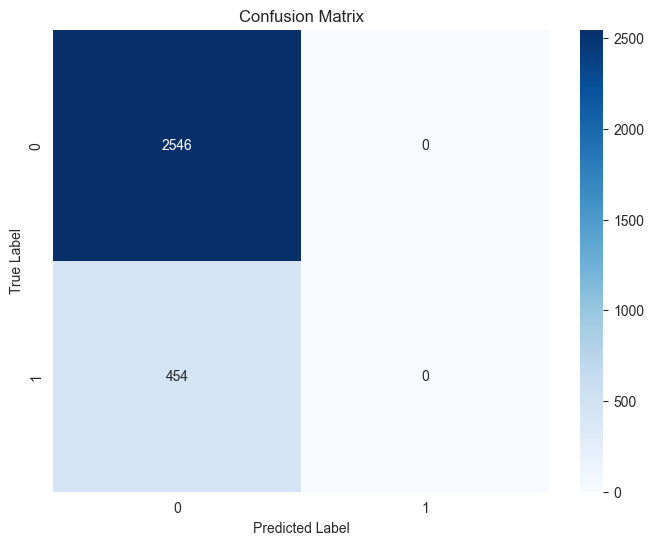

In [9]:
# Make predictions
prevision = model.predict(test_x)
print("Treinaremos com %d elementos e testaremos com %d elementos" % (len(train_x), len(test_x)))

# Calculate accuracy
accuracy_value = accuracy_score(test_y, prevision) * 100
print("A acurácia foi %.2f%%" % accuracy_value)

# Calculate F1 score
f1_value = f1_score(test_y, prevision, average="weighted")  # Use 'weighted' for imbalanced classes
print("O F1 Score foi %.2f" % f1_value)

# Generate confusion matrix
conf_matrix = confusion_matrix(test_y, prevision)
print("Matriz de Confusão:\n", conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.show()

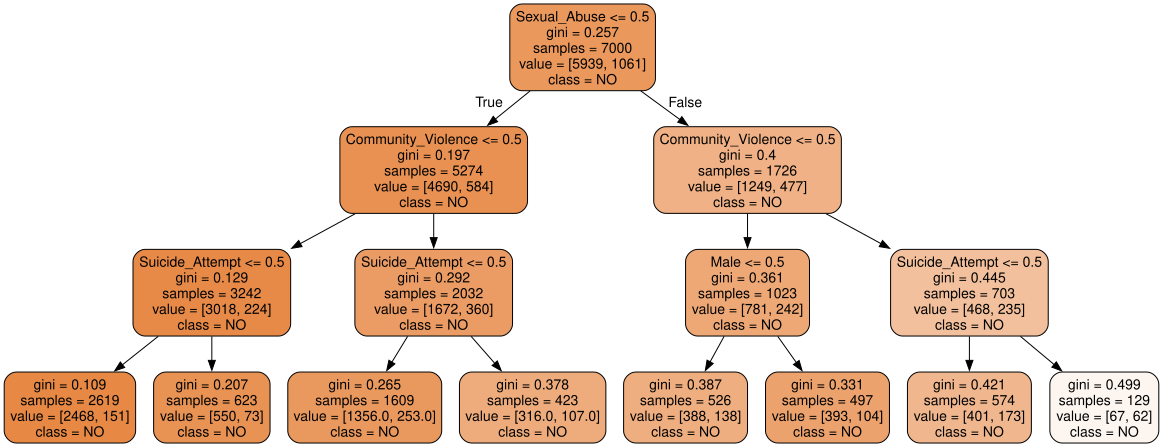

In [10]:
from sklearn.tree import export_graphviz
import graphviz

features = x.columns
dot_data = export_graphviz(model, out_file=None,
                           filled=True, rounded=True,
                           feature_names=features,
                           class_names=["NO", "YES"])
grafico = graphviz.Source(dot_data)
grafico